In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('Libraries imported.')

Libraries imported.


## 1. Load Dataset

In [41]:
df = pd.read_csv('preprocessed_data_v2.csv')
TARGET = 'spam'

print(f'Dataset shape    : {df.shape}')
print(f'Class distribution:')
print(df[TARGET].value_counts())

Dataset shape    : (5062, 79)
Class distribution:
spam
1    2531
0    2531
Name: count, dtype: int64


## 2. Select Original 57 Features

Drop the 21 engineered features — use only the original spambase features.

In [42]:
X_all = df.drop(TARGET, axis=1)
y     = df[TARGET]

engineered_prefixes = [
    'spam_word', 'ham_word', 'spam_ham', 'char_spam',
    'char_ham', 'capital_ratio', 'word_present', 'word_diversity'
]
feature_names = [
    c for c in X_all.columns
    if not any(c.startswith(p) for p in engineered_prefixes)
]

X = X_all[feature_names]
print(f'Original features selected : {len(feature_names)}')

Original features selected : 57


## 3. Train-Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

print(f'Training set : {X_train.shape}')
print(f'Testing set  : {X_test.shape}')

Training set : (4049, 57)
Testing set  : (1013, 57)


## 4. Feature Scaling (StandardScaler)

In [44]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print('StandardScaler applied.')

StandardScaler applied.


## 5. Train XGBoost Model

In [45]:
model = XGBClassifier(eval_metric='logloss', n_jobs=-1, verbosity=0, random_state=42)
model.fit(X_train_std, y_train)

train_pred = model.predict(X_train_std)
test_pred  = model.predict(X_test_std)

train_acc = accuracy_score(y_train, train_pred) * 100
test_acc  = accuracy_score(y_test,  test_pred)  * 100

print(f'Train Accuracy : {train_acc:.3f}%')
print(f'Test  Accuracy : {test_acc:.3f}%')

Train Accuracy : 99.827%
Test  Accuracy : 97.038%


## 6. Evaluation

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Ham (0)       0.97      0.97      0.97       513
    Spam (1)       0.97      0.97      0.97       500

    accuracy                           0.97      1013
   macro avg       0.97      0.97      0.97      1013
weighted avg       0.97      0.97      0.97      1013



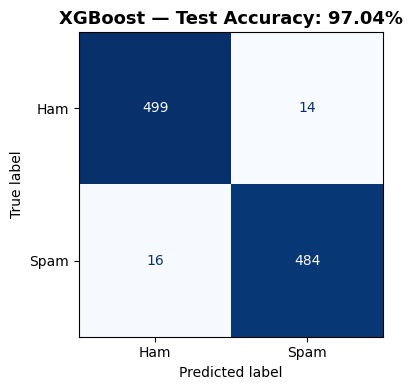

In [46]:
print('=' * 70)
print('CLASSIFICATION REPORT')
print('=' * 70)
print(classification_report(y_test, test_pred, target_names=['Ham (0)', 'Spam (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'XGBoost — Test Accuracy: {test_acc:.2f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('best_xgboost_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE IMPORTANCES (Top 20)


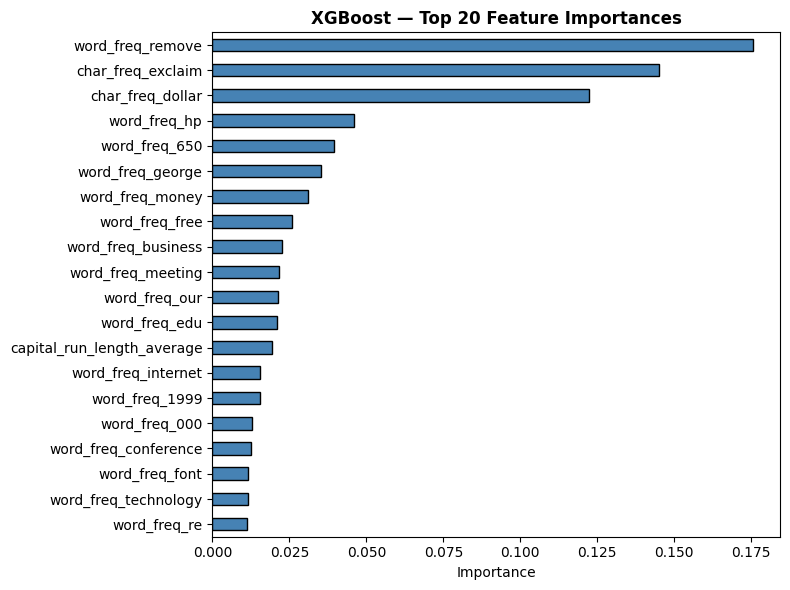

In [47]:
print('=' * 70)
print('FEATURE IMPORTANCES (Top 20)')
print('=' * 70)
importances = pd.Series(model.feature_importances_, index=feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('best_xgboost_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()